In [48]:
import pandas as pd
import numpy as np

TEMPORAL_PATH = r"C:\code\data\procesed\02-14-2018_temporal_states.csv"

state_df = pd.read_csv(TEMPORAL_PATH)

state_df["time_window"] = pd.to_datetime(
    state_df["time_window"],
    errors="raise"
)

state_df = state_df.sort_values("time_window").reset_index(drop=True)

print("Shape:", state_df.shape)
print(state_df["time_window"].head())

Shape: (6509, 33)
0   2018-02-14 01:00:00
1   2018-02-14 01:00:05
2   2018-02-14 01:00:10
3   2018-02-14 01:00:15
4   2018-02-14 01:00:20
Name: time_window, dtype: datetime64[us]


In [49]:
STATE_FEATURES = [
    "Tot Fwd Pkts",
    "Tot Bwd Pkts",
    "TotLen Fwd Pkts",
    "TotLen Bwd Pkts",
    "Flow Byts/s",
    "Flow Pkts/s",

    "Flow Duration",
    "Fwd Pkt Len Mean",
    "Bwd Pkt Len Mean",
    "Fwd Pkt Len Std",
    "Bwd Pkt Len Std",

    "Flow IAT Mean",
    "Flow IAT Std",
    "Flow IAT Max",
    "Flow IAT Min",

    "SYN Flag Cnt",
    "ACK Flag Cnt",
    "RST Flag Cnt",
    "FIN Flag Cnt",
    "PSH Flag Cnt",

    "Pkt Len Min",
    "Pkt Len Max",
    "Pkt Len Mean",
    "Pkt Len Std",
    "Pkt Size Avg",

    "Dst Port",
    "Protocol"
]

In [50]:
missing = [
    col for col in STATE_FEATURES
    if col not in state_df.columns
]

print("Missing features:", missing)
print("Number of state features:", len(STATE_FEATURES))

Missing features: []
Number of state features: 27


In [51]:
X_current = state_df[STATE_FEATURES].iloc[:-1].to_numpy(
    dtype=np.float32
)

X_next = state_df[STATE_FEATURES].iloc[1:].to_numpy(
    dtype=np.float32
)

print("X_current:", X_current.shape)
print("X_next:", X_next.shape)

X_current: (6508, 27)
X_next: (6508, 27)


In [52]:
y_attack_next = state_df["IsAttack"].iloc[1:].to_numpy(
    dtype=np.int8
)

y_ratio_next = state_df["attack_ratio"].iloc[1:].to_numpy(
    dtype=np.float32
)

y_stage_next = state_df["AttackStage"].iloc[1:].to_numpy()

print("Attack target:", y_attack_next.shape)
print("Ratio target:", y_ratio_next.shape)
print("Stage target:", y_stage_next.shape)

Attack target: (6508,)
Ratio target: (6508,)
Stage target: (6508,)


In [53]:
time_diff = state_df["time_window"].diff().dt.total_seconds()

print(time_diff.describe())
print(
    "Gaps > 5 seconds:",
    (time_diff > 5).sum()
)

count     6508.000000
mean         6.637216
std        132.015782
min          5.000000
25%          5.000000
50%          5.000000
75%          5.000000
max      10655.000000
Name: time_window, dtype: float64
Gaps > 5 seconds: 2


In [54]:
gap_mask = time_diff > 5

print(
    state_df.loc[
        gap_mask,
        ["time_window"]
    ]
)

print(time_diff[gap_mask])

             time_window
3248 2018-02-14 05:30:45
3249 2018-02-14 08:28:20
3248       10.0
3249    10655.0
Name: time_window, dtype: float64


In [55]:
# Sort just to be safe
state_df = state_df.sort_values("time_window").reset_index(drop=True)

# Time difference between states
state_df["time_delta"] = (
    state_df["time_window"].diff().dt.total_seconds()
)

# A new segment starts whenever the gap is > 5 seconds
state_df["segment_id"] = (
    state_df["time_delta"].gt(5)
    .cumsum()
)

print(state_df["segment_id"].value_counts().sort_index())

segment_id
0    3248
1       1
2    3260
Name: count, dtype: int64


In [56]:
segments = state_df.groupby("segment_id").agg(
    start=("time_window", "min"),
    end=("time_window", "max"),
    states=("time_window", "size")
)

print(segments)

                         start                 end  states
segment_id                                                
0          2018-02-14 01:00:00 2018-02-14 05:30:35    3248
1          2018-02-14 05:30:45 2018-02-14 05:30:45       1
2          2018-02-14 08:28:20 2018-02-14 12:59:55    3260


In [57]:
SEQUENCE_LENGTH = 20

X_sequences = []
y_next_state = []

y_attack = []
y_attack_ratio = []
y_stage = []

for segment_id, segment in state_df.groupby("segment_id"):

    segment = segment.sort_values("time_window").reset_index(drop=True)

    # Skip segments that are too short
    if len(segment) <= SEQUENCE_LENGTH:
        continue

    features = segment[STATE_FEATURES].to_numpy(
        dtype=np.float32
    )

    attack = segment["IsAttack"].to_numpy(
        dtype=np.float32
    )

    ratio = segment["attack_ratio"].to_numpy(
        dtype=np.float32
    )

    stages = segment["AttackStage"].to_numpy()

    for i in range(SEQUENCE_LENGTH, len(segment)):

        # Previous 20 network states
        X_sequences.append(
            features[i-SEQUENCE_LENGTH:i]
        )

        # Future state S(t+1) / current target state
        y_next_state.append(
            features[i]
        )

        # Attack status of predicted state
        y_attack.append(
            attack[i]
        )

        # Attack intensity
        y_attack_ratio.append(
            ratio[i]
        )

        # Attack stage
        y_stage.append(
            stages[i]
        )

In [58]:
X_sequences = np.asarray(
    X_sequences,
    dtype=np.float32
)

y_next_state = np.asarray(
    y_next_state,
    dtype=np.float32
)

y_attack = np.asarray(
    y_attack,
    dtype=np.float32
)

y_attack_ratio = np.asarray(
    y_attack_ratio,
    dtype=np.float32
)

y_stage = np.asarray(
    y_stage
)

In [59]:
print("X:", X_sequences.shape)
print("Next state:", y_next_state.shape)
print("Attack:", y_attack.shape)
print("Attack ratio:", y_attack_ratio.shape)
print("Stage:", y_stage.shape)

X: (6468, 20, 27)
Next state: (6468, 27)
Attack: (6468,)
Attack ratio: (6468,)
Stage: (6468,)


In [60]:
n = len(X_sequences)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X_sequences[:train_end]
X_val   = X_sequences[train_end:val_end]
X_test  = X_sequences[val_end:]

y_state_train = y_next_state[:train_end]
y_state_val   = y_next_state[train_end:val_end]
y_state_test  = y_next_state[val_end:]

y_attack_train = y_attack[:train_end]
y_attack_val   = y_attack[train_end:val_end]
y_attack_test  = y_attack[val_end:]

y_ratio_train = y_attack_ratio[:train_end]
y_ratio_val   = y_attack_ratio[train_end:val_end]
y_ratio_test  = y_attack_ratio[val_end:]

y_stage_train = y_stage[:train_end]
y_stage_val   = y_stage[train_end:val_end]
y_stage_test  = y_stage[val_end:]

In [61]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (4527, 20, 27)
Validation: (970, 20, 27)
Test: (971, 20, 27)


In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Flatten temporal dimension
X_train_flat = X_train.reshape(-1, X_train.shape[-1])

scaler.fit(X_train_flat)

StandardScaler()

In [63]:
X_train_scaled = scaler.transform(
    X_train.reshape(-1, 27)
).reshape(X_train.shape)

X_val_scaled = scaler.transform(
    X_val.reshape(-1, 27)
).reshape(X_val.shape)

X_test_scaled = scaler.transform(
    X_test.reshape(-1, 27)
).reshape(X_test.shape)

In [64]:
y_state_train_scaled = scaler.transform(y_state_train)
y_state_val_scaled = scaler.transform(y_state_val)
y_state_test_scaled = scaler.transform(y_state_test)

In [65]:
print("Train mean:", X_train_scaled.mean())
print("Train std:", X_train_scaled.std())

Train mean: 6.391691e-09
Train std: 1.0


In [66]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.21.0
GPU: []


In [67]:
from sklearn.preprocessing import LabelEncoder

stage_encoder = LabelEncoder()

y_stage_train_encoded = stage_encoder.fit_transform(y_stage_train)
y_stage_val_encoded = stage_encoder.transform(y_stage_val)
y_stage_test_encoded = stage_encoder.transform(y_stage_test)

print("Stages:", stage_encoder.classes_)

Stages: ['Benign' 'Initial Access']


In [68]:

from tensorflow import keras
from tensorflow.keras import layers

N_FEATURES = X_train_scaled.shape[-1]
N_STAGES = len(stage_encoder.classes_)

inputs = keras.Input(
    shape=(20, N_FEATURES),
    name="network_state_sequence"
)

x = layers.LSTM(
    128,
    return_sequences=True,
    name="temporal_encoder_1"
)(inputs)

x = layers.Dropout(0.2)(x)

x = layers.LSTM(
    64,
    name="temporal_encoder_2"
)(x)

latent = layers.Dense(
    64,
    activation="relu",
    name="latent_network_state"
)(x)

In [69]:
next_state = layers.Dense(
    N_FEATURES,
    name="next_state"
)(latent)

attack_probability = layers.Dense(
    1,
    activation="sigmoid",
    name="attack_probability"
)(latent)

attack_ratio = layers.Dense(
    1,
    activation="sigmoid",
    name="attack_ratio"
)(latent)

attack_stage = layers.Dense(
    N_STAGES,
    activation="softmax",
    name="attack_stage"
)(latent)

In [70]:
world_model = keras.Model(
    inputs=inputs,
    outputs=[
        next_state,
        attack_probability,
        attack_ratio,
        attack_stage
    ],
    name="CyberWorldModel"
)

world_model.summary()

Model: "CyberWorldModel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ network_state_sequ… │ (None, 20, 27)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_encoder_1  │ (None, 20, 128)   │     79,872 │ network_state_se… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 20, 128)   │          0 │ temporal_encoder… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ temporal_encoder_2  │ (None, 64)        │     49,408 │ dropout_1[0][0]   │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent_network_sta… │ (None, 64)        │      4,160 │ temporal_encoder… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ next_state (Dense)  │ (None, 27)        │      1,755 │ latent_network_s… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attack_probability  │ (None, 1)         │         65 │ latent_network_s… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attack_ratio        │ (None, 1)         │         65 │ latent_network_s… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attack_stage        │ (None, 2)         │        130 │ latent_network_s… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 135,455 (529.12 KB)

 Trainable params: 135,455 (529.12 KB)

 Non-trainable params: 0 (0.00 B)

In [71]:
world_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss={
        "next_state": "mse",
        "attack_probability": "binary_crossentropy",
        "attack_ratio": "mse",
        "attack_stage": "sparse_categorical_crossentropy"
    },

    loss_weights={
        "next_state": 1.0,
        "attack_probability": 2.0,
        "attack_ratio": 1.0,
        "attack_stage": 1.0
    },

    metrics={
        "attack_probability": [
            "accuracy",
            keras.metrics.AUC(name="auc")
        ],

        "attack_stage": [
            "accuracy"
        ]
    }
)

In [72]:
[name for name in globals() if name.startswith(("X_", "y_", "N_", "world_"))]

['X_current',
 'X_next',
 'y_attack_next',
 'y_ratio_next',
 'y_stage_next',
 'X_sequences',
 'y_next_state',
 'y_attack',
 'y_attack_ratio',
 'y_stage',
 'X_train',
 'X_val',
 'X_test',
 'y_state_train',
 'y_state_val',
 'y_state_test',
 'y_attack_train',
 'y_attack_val',
 'y_attack_test',
 'y_ratio_train',
 'y_ratio_val',
 'y_ratio_test',
 'y_stage_train',
 'y_stage_val',
 'y_stage_test',
 'X_train_flat',
 'X_train_scaled',
 'X_val_scaled',
 'X_test_scaled',
 'y_state_train_scaled',
 'y_state_val_scaled',
 'y_state_test_scaled',
 'y_stage_train_encoded',
 'y_stage_val_encoded',
 'y_stage_test_encoded',
 'N_FEATURES',
 'N_STAGES',
 'world_model']

In [73]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

history = world_model.fit(
    X_train_scaled,

    {
        "next_state": y_state_train_scaled,
        "attack_probability": y_attack_train,
        "attack_ratio": y_ratio_train,
        "attack_stage": y_stage_train_encoded
    },

    validation_data=(
        X_val_scaled,
        {
            "next_state": y_state_val_scaled,
            "attack_probability": y_attack_val,
            "attack_ratio": y_ratio_val,
            "attack_stage": y_stage_val_encoded
        }
    ),

    epochs=30,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - attack_probability_accuracy: 0.9894 - attack_probability_auc: 0.9966 - attack_probability_loss: 0.0993 - attack_ratio_loss: 0.0382 - attack_stage_accuracy: 0.9770 - attack_stage_loss: 0.1055 - loss: 1.2514 - next_state_loss: 0.9074 - val_attack_probability_accuracy: 0.2825 - val_attack_probability_auc: 0.7860 - val_attack_probability_loss: 3.1382 - val_attack_ratio_loss: 0.0333 - val_attack_stage_accuracy: 0.2959 - val_attack_stage_loss: 2.9563 - val_loss: 10.8071 - val_next_state_loss: 1.2652 - learning_rate: 0.0010
Epoch 2/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - attack_probability_accuracy: 0.9982 - attack_probability_auc: 0.9993 - attack_probability_loss: 0.0094 - attack_ratio_loss: 0.0059 - attack_stage_accuracy: 0.9982 - attack_stage_loss: 0.0087 - loss: 0.7993 - next_state_loss: 0.7650 - val_attack_probability_accuracy: 0.3753 - val_attack_probability_auc: 0.8598 - val_attack_probability_loss: 2.5698 - val_attack_ratio_los

In [74]:
MODEL_PATH = r"C:\code\inference\models\world_model.keras"

world_model.save(MODEL_PATH)

print("Model saved:", MODEL_PATH)

Model saved: C:\code\inference\models\world_model.keras


In [75]:
import joblib

In [76]:
ENCODER_PATH = r"C:\code\inference\models\stage_encoder.pkl"

joblib.dump(
    stage_encoder,
    ENCODER_PATH
)

print("Encoder saved:", ENCODER_PATH)

Encoder saved: C:\code\inference\models\stage_encoder.pkl


In [77]:
from pathlib import Path

MODEL_DIR = Path(r"C:\code\inference\models")

for file in MODEL_DIR.iterdir():
    if file.is_file():
        print(f"{file.name:25} {file.stat().st_size / (1024**2):.2f} MB")

stage_encoder.pkl         0.00 MB
state_scaler.pkl          0.00 MB
world_model.keras         1.61 MB


In [78]:
SCALER_PATH = r"C:\code\inference\models\state_scaler.pkl"

joblib.dump(scaler, SCALER_PATH)

print("Saved:", SCALER_PATH)

Saved: C:\code\inference\models\state_scaler.pkl


In [81]:
scaler = joblib.load(
    r"C:\code\inference\models\state_scaler.pkl"
)

stage_encoder = joblib.load(
    r"C:\code\inference\models\stage_encoder.pkl"
)

loaded_model = tf.keras.models.load_model(
    r"C:\code\inference\models\world_model.keras"
)

print("Scaler:", type(scaler))
print("Stages:", stage_encoder.classes_)
print("Model:", loaded_model.name)

Scaler: <class 'sklearn.preprocessing._data.StandardScaler'>
Stages: ['Benign' 'Initial Access']
Model: CyberWorldModel


In [82]:
test_predictions = world_model.predict(
    X_test_scaled,
    batch_size=64,
    verbose=1
)

pred_next_state = test_predictions[0]
pred_attack_prob = test_predictions[1].ravel()
pred_attack_ratio = test_predictions[2].ravel()
pred_stage_prob = test_predictions[3]

print("Next state:", pred_next_state.shape)
print("Attack probability:", pred_attack_prob.shape)
print("Attack ratio:", pred_attack_ratio.shape)
print("Attack stage:", pred_stage_prob.shape)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
Next state: (971, 27)
Attack probability: (971,)
Attack ratio: (971,)
Attack stage: (971, 2)


In [101]:
pred_attack = (
    pred_attack_prob >= 0.05
).astype(np.int8)

In [102]:
print("Actual:")
print(pd.Series(y_attack_test).value_counts())

print("\nPredicted:")
print(pd.Series(pred_attack).value_counts())

Actual:
0.0    593
1.0    378
Name: count, dtype: int64

Predicted:
0    644
1    327
Name: count, dtype: int64


In [103]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

precision = precision_score(
    y_attack_test,
    pred_attack,
    zero_division=0
)

recall = recall_score(
    y_attack_test,
    pred_attack,
    zero_division=0
)

f1 = f1_score(
    y_attack_test,
    pred_attack,
    zero_division=0
)

auc = roc_auc_score(
    y_attack_test,
    pred_attack_prob
)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {auc:.4f}")

Precision: 0.9664
Recall:    0.8360
F1 Score:  0.8965
ROC-AUC:   0.9667


In [104]:
cm = confusion_matrix(
    y_attack_test,
    pred_attack
)

tn, fp, fn, tp = cm.ravel()

fpr = fp / (fp + tn)

print("Confusion Matrix:")
print(cm)

print(f"\nTN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")

print(f"\nFalse Positive Rate: {fpr:.4f}")

Confusion Matrix:
[[582  11]
 [ 62 316]]

TN: 582
FP: 11
FN: 62
TP: 316

False Positive Rate: 0.0185


In [105]:
print(
    classification_report(
        y_attack_test,
        pred_attack,
        target_names=["Benign", "Attack"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

      Benign       0.90      0.98      0.94       593
      Attack       0.97      0.84      0.90       378

    accuracy                           0.92       971
   macro avg       0.94      0.91      0.92       971
weighted avg       0.93      0.92      0.92       971



In [106]:
pred_stage = np.argmax(
    pred_stage_prob,
    axis=1
)

print(
    classification_report(
        y_stage_test_encoded,
        pred_stage,
        target_names=stage_encoder.classes_,
        zero_division=0
    )
)

                precision    recall  f1-score   support

        Benign       0.82      0.99      0.90       593
Initial Access       0.98      0.67      0.80       378

      accuracy                           0.87       971
     macro avg       0.90      0.83      0.85       971
  weighted avg       0.89      0.87      0.86       971



In [107]:
from sklearn.metrics import accuracy_score

stage_accuracy = accuracy_score(
    y_stage_test_encoded,
    pred_stage
)

print(
    f"Attack-stage accuracy: {stage_accuracy:.4f}"
)


Attack-stage accuracy: 0.8671


In [108]:
from sklearn.metrics import mean_squared_error

state_mse = mean_squared_error(
    y_state_test_scaled,
    pred_next_state
)

state_rmse = np.sqrt(state_mse)

print(f"Next-state MSE:  {state_mse:.6f}")
print(f"Next-state RMSE: {state_rmse:.6f}")

Next-state MSE:  12.284738
Next-state RMSE: 3.504959


In [109]:
pred_next_state_original = scaler.inverse_transform(
    pred_next_state
)

actual_next_state_original = scaler.inverse_transform(
    y_state_test_scaled
)

state_rmse_original = np.sqrt(
    mean_squared_error(
        actual_next_state_original,
        pred_next_state_original
    )
)

print(
    f"Original-scale RMSE: {state_rmse_original:.4f}"
)

Original-scale RMSE: 3102364.2832


In [110]:
ratio_rmse = np.sqrt(
    mean_squared_error(
        y_ratio_test,
        pred_attack_ratio
    )
)

print(
    f"Attack-ratio RMSE: {ratio_rmse:.4f}"
)

Attack-ratio RMSE: 0.1813


In [111]:
evaluation_results = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "False Positive Rate",
        "Attack Stage Accuracy",
        "Next-State RMSE",
        "Attack-Ratio RMSE"
    ],

    "World Model": [
        precision,
        recall,
        f1,
        auc,
        fpr,
        stage_accuracy,
        state_rmse,
        ratio_rmse
    ]
})

evaluation_results

,Metric,World Model
0,Precision,0.966361
1,Recall,0.835979
2,F1 Score,0.896454
3,ROC-AUC,0.966728
4,False Positive Rate,0.018550
5,Attack Stage Accuracy,0.867147
6,Next-State RMSE,3.504959
7,Attack-Ratio RMSE,0.181271


Confusion Matrix:
[[582  11]
 [ 62 316]]
TN: 582
FP: 11
FN: 62
TP: 316


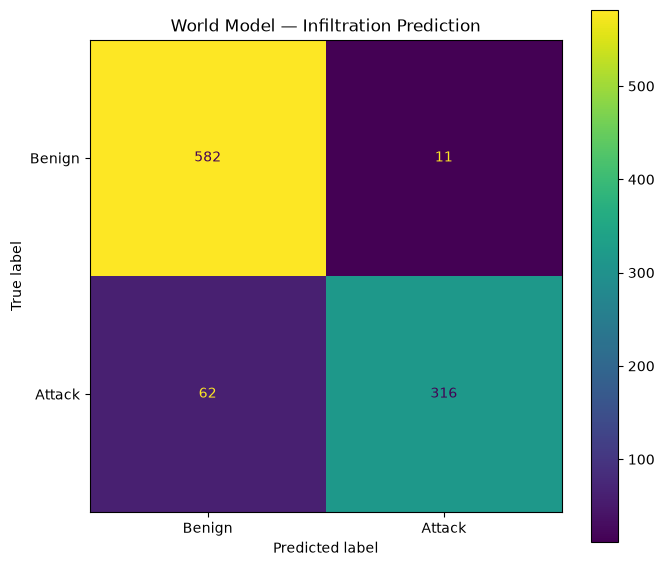

In [112]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_attack_test,
    pred_attack,
    labels=[0, 1]
)

print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print(f"TN: {tn}")
print(f"FP: {fp}")
print(f"FN: {fn}")
print(f"TP: {tp}")

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Attack"]
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    values_format="d"
)

ax.set_title(
    "World Model — Infiltration Prediction"
)

plt.tight_layout()
plt.show()

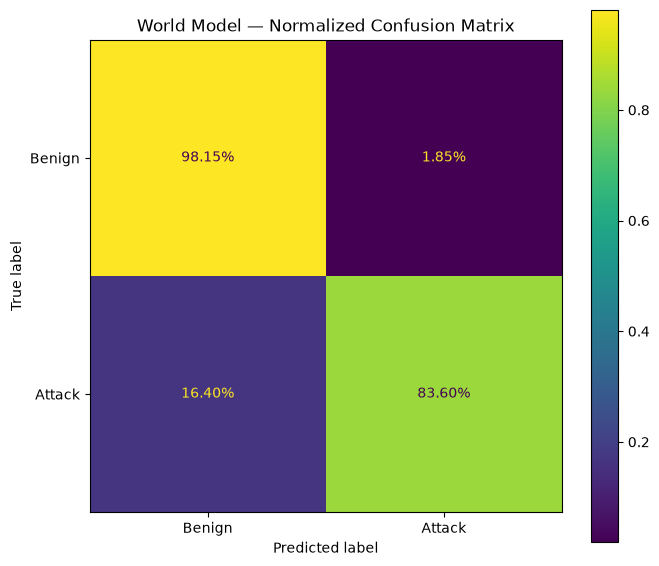

In [113]:
cm_norm = confusion_matrix(
    y_attack_test,
    pred_attack,
    labels=[0, 1],
    normalize="true"
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_norm,
    display_labels=["Benign", "Attack"]
)

fig, ax = plt.subplots(figsize=(7, 6))

disp.plot(
    ax=ax,
    values_format=".2%"
)

ax.set_title(
    "World Model — Normalized Confusion Matrix"
)

plt.tight_layout()
plt.show()